<a href="https://colab.research.google.com/github/sammygoesbrrr/Differential-Equation/blob/main/Problem_set_1_1_Strang_DELA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

At t = 0 : y1 = 1.0000, y2 = 2.0000 --> y2 is larger
At t = 1 : y1 = 7.3891, y2 = 5.4366 --> y1 is larger
Intersection: t = 0.6931 (ln(2)), y = 4.0000


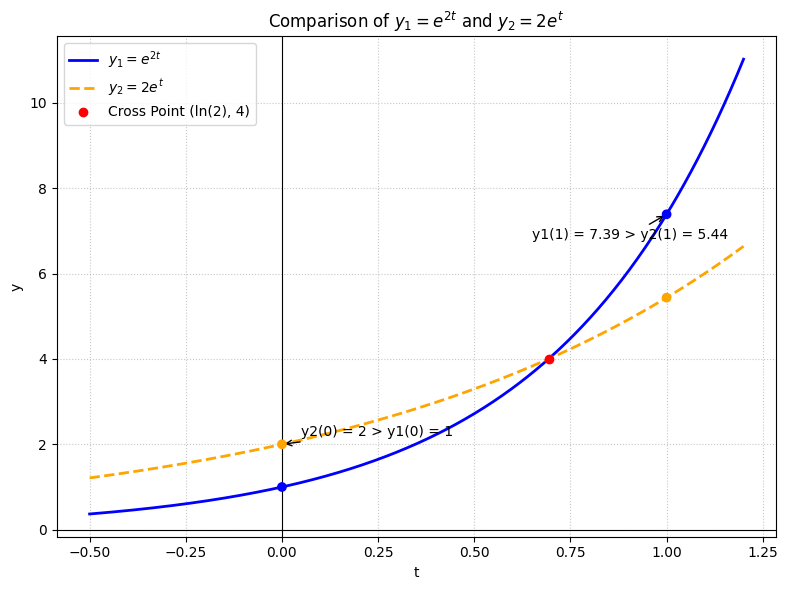

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root_scalar

# 1. Define mathematical functions
y1 = lambda t: np.exp(2 * t)
y2 = lambda t: 2 * np.exp(t)
f_diff = lambda t: y1(t) - y2(t)  # Difference function

# 2. Evaluate values at key points
y1_0, y2_0 = y1(0.0), y2(0.0)
y1_1, y2_1 = y1(1.0), y2(1.0)

# 3. Use SciPy root_scalar to find the exact intersection point
sol = root_scalar(f_diff, bracket=[0, 1], method="brentq")
t_cross = sol.root
y_cross = y1(t_cross)

print(f"At t = 0 : y1 = {y1_0:.4f}, y2 = {y2_0:.4f} --> y2 is larger")
print(f"At t = 1 : y1 = {y1_1:.4f}, y2 = {y2_1:.4f} --> y1 is larger")
print(
    f"Intersection: t = {t_cross:.4f} (ln(2)), y = {y_cross:.4f}"
)

# 4. Generate Visualization Plot
t_vals = np.linspace(-0.5, 1.2, 500)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the two functions
ax.plot(t_vals, y1(t_vals), label=r"$y_1 = e^{2t}$", color="blue", lw=2)
ax.plot(
    t_vals,
    y2(t_vals),
    label=r"$y_2 = 2e^t$",
    color="orange",
    linestyle="--",
    lw=2,
)

# Highlight evaluation points at t=0 and t=1
ax.scatter([0, 0], [y1_0, y2_0], color=["blue", "orange"], zorder=5)
ax.annotate(
    f"y2(0) = {y2_0:.0f} > y1(0) = {y1_0:.0f}",
    xy=(0, 2),
    xytext=(0.05, 2.2),
    arrowprops=dict(arrowstyle="->", color="black"),
)

ax.scatter([1, 1], [y1_1, y2_1], color=["blue", "orange"], zorder=5)
ax.annotate(
    f"y1(1) = {y1_1:.2f} > y2(1) = {y2_1:.2f}",
    xy=(1, y1_1),
    xytext=(0.65, 6.8),
    arrowprops=dict(arrowstyle="->", color="black"),
)

# Highlight the crossing point
ax.scatter(
    [t_cross],
    [y_cross],
    color="red",
    zorder=6,
    label=f"Cross Point (ln(2), 4)",
)

# Formatting
ax.set_title(r"Comparison of $y_1 = e^{2t}$ and $y_2 = 2e^t$")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, linestyle=":", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()